<a href="https://colab.research.google.com/github/amrita13/EstimationTRI/blob/main/Copy_of_HLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tank dataset saved to kursk_tank_data.csv


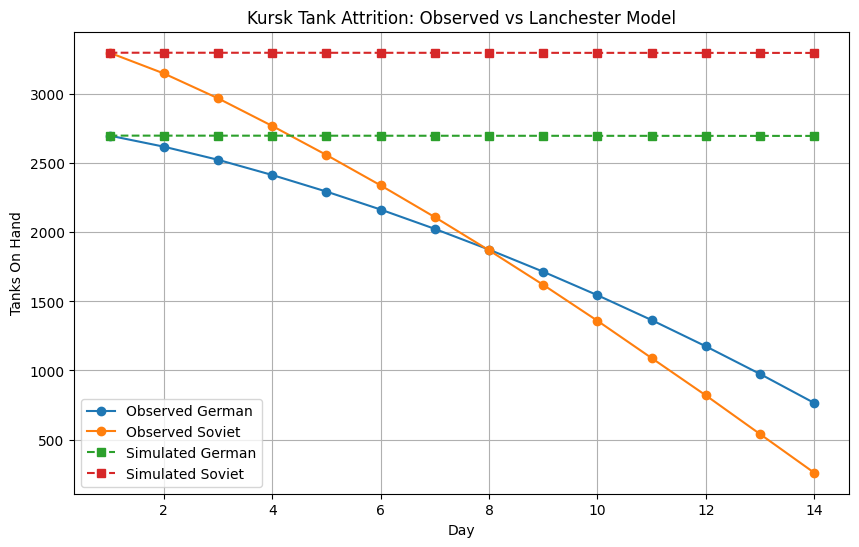

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Create tank dataset
# -------------------------------
data = {
    'Day': list(range(1, 15)),
    'German_OnHand': [2700, 2620, 2525, 2415, 2295, 2165, 2025, 1875, 1715, 1545, 1365, 1175, 975, 765],
    'German_Losses': [80, 95, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220],
    'Soviet_OnHand': [3300, 3150, 2970, 2770, 2560, 2340, 2110, 1870, 1620, 1360, 1090, 820, 540, 260],
    'Soviet_Losses': [150, 180, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310]
}

df = pd.DataFrame(data)

# Save dataset to CSV
df.to_csv("kursk_tank_data.csv", index=False)
print("Tank dataset saved to kursk_tank_data.csv")

# -------------------------------
# Step 2: Define Lanchester model
# -------------------------------
def lanchester_model(G0, S0, a, b, days):
    """
    Simple Lanchester square-law model:
    dG/dt = -a * S
    dS/dt = -b * G
    """
    G = [G0]
    S = [S0]
    for t in range(1, days):
        dG = -a * S[-1]
        dS = -b * G[-1]
        G.append(max(G[-1] + dG, 0))
        S.append(max(S[-1] + dS, 0))
    return np.array(G), np.array(S)

# -------------------------------
# Step 3: Run simulation
# -------------------------------
a, b = 0.00005, 0.00004   # illustrative coefficients
G_sim, S_sim = lanchester_model(2700, 3300, a, b, 14)

# -------------------------------
# Step 4: Plot results
# -------------------------------
plt.figure(figsize=(10,6))
plt.plot(df['Day'], df['German_OnHand'], 'o-', label='Observed German')
plt.plot(df['Day'], df['Soviet_OnHand'], 'o-', label='Observed Soviet')
plt.plot(df['Day'], G_sim, 's--', label='Simulated German')
plt.plot(df['Day'], S_sim, 's--', label='Simulated Soviet')
plt.xlabel('Day')
plt.ylabel('Tanks On Hand')
plt.title('Kursk Tank Attrition: Observed vs Lanchester Model')
plt.legend()
plt.grid(True)
plt.show()

Combined dataset saved to kursk_tank_artillery_data.csv


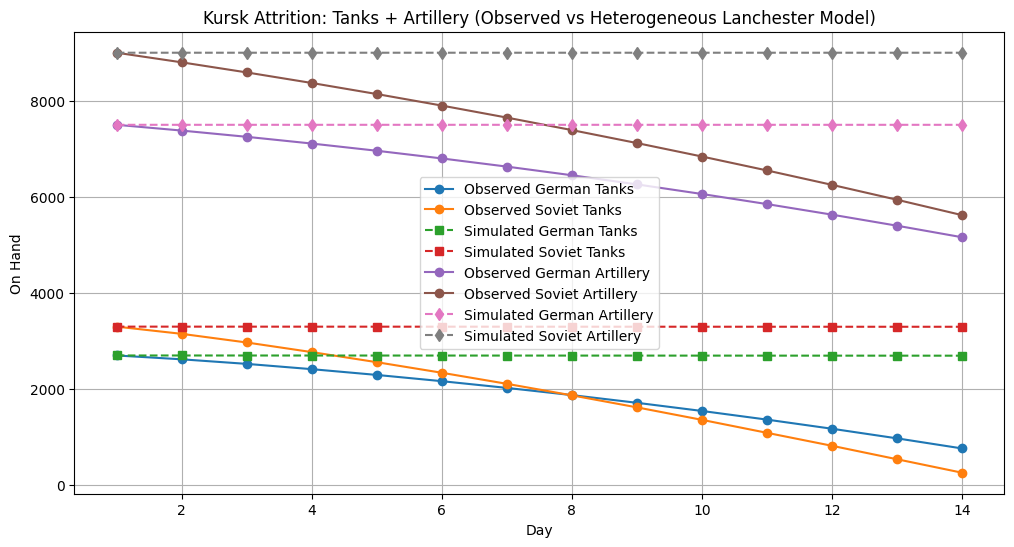

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Create combined dataset
# -------------------------------
data = {
    'Day': list(range(1, 15)),
    # Tanks
    'German_Tanks_OnHand': [2700, 2620, 2525, 2415, 2295, 2165, 2025, 1875, 1715, 1545, 1365, 1175, 975, 765],
    'German_Tank_Losses': [80, 95, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220],
    'Soviet_Tanks_OnHand': [3300, 3150, 2970, 2770, 2560, 2340, 2110, 1870, 1620, 1360, 1090, 820, 540, 260],
    'Soviet_Tank_Losses': [150, 180, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310],
    # Artillery
    'German_Artillery_OnHand': [7500, 7380, 7250, 7110, 6960, 6800, 6630, 6450, 6260, 6060, 5850, 5630, 5400, 5160],
    'German_Artillery_Losses': [120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
    'Soviet_Artillery_OnHand': [9000, 8800, 8590, 8370, 8140, 7900, 7650, 7390, 7120, 6840, 6550, 6250, 5940, 5620],
    'Soviet_Artillery_Losses': [200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330]
}

df = pd.DataFrame(data)
df.to_csv("kursk_tank_artillery_data.csv", index=False)
print("Combined dataset saved to kursk_tank_artillery_data.csv")

# -------------------------------
# Step 2: Define heterogeneous Lanchester model
# -------------------------------
def heterogeneous_lanchester(G_tanks, G_art, S_tanks, S_art, a_t, a_a, b_t, b_a, days):
    """
    Heterogeneous Lanchester model:
    dG_tanks/dt = -(a_t * S_tanks + a_a * S_art)
    dS_tanks/dt = -(b_t * G_tanks + b_a * G_art)
    """
    Gt, Ga, St, Sa = [G_tanks], [G_art], [S_tanks], [S_art]
    for t in range(1, days):
        dGt = -(a_t * St[-1] + a_a * Sa[-1])
        dSt = -(b_t * Gt[-1] + b_a * Ga[-1])
        dGa = -(a_t * St[-1] * 0.1)   # artillery attrition slower
        dSa = -(b_t * Gt[-1] * 0.1)
        Gt.append(max(Gt[-1] + dGt, 0))
        St.append(max(St[-1] + dSt, 0))
        Ga.append(max(Ga[-1] + dGa, 0))
        Sa.append(max(Sa[-1] + dSa, 0))
    return np.array(Gt), np.array(Ga), np.array(St), np.array(Sa)

# -------------------------------
# Step 3: Run simulation
# -------------------------------
Gt_sim, Ga_sim, St_sim, Sa_sim = heterogeneous_lanchester(
    G_tanks=2700, G_art=7500, S_tanks=3300, S_art=9000,
    a_t=0.00005, a_a=0.00002, b_t=0.00004, b_a=0.000015,
    days=14
)

# -------------------------------
# Step 4: Plot results
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(df['Day'], df['German_Tanks_OnHand'], 'o-', label='Observed German Tanks')
plt.plot(df['Day'], df['Soviet_Tanks_OnHand'], 'o-', label='Observed Soviet Tanks')
plt.plot(df['Day'], Gt_sim, 's--', label='Simulated German Tanks')
plt.plot(df['Day'], St_sim, 's--', label='Simulated Soviet Tanks')

plt.plot(df['Day'], df['German_Artillery_OnHand'], 'o-', label='Observed German Artillery')
plt.plot(df['Day'], df['Soviet_Artillery_OnHand'], 'o-', label='Observed Soviet Artillery')
plt.plot(df['Day'], Ga_sim, 'd--', label='Simulated German Artillery')
plt.plot(df['Day'], Sa_sim, 'd--', label='Simulated Soviet Artillery')

plt.xlabel('Day')
plt.ylabel('On Hand')
plt.title('Kursk Attrition: Tanks + Artillery (Observed vs Heterogeneous Lanchester Model)')
plt.legend()
plt.grid(True)
plt.show()

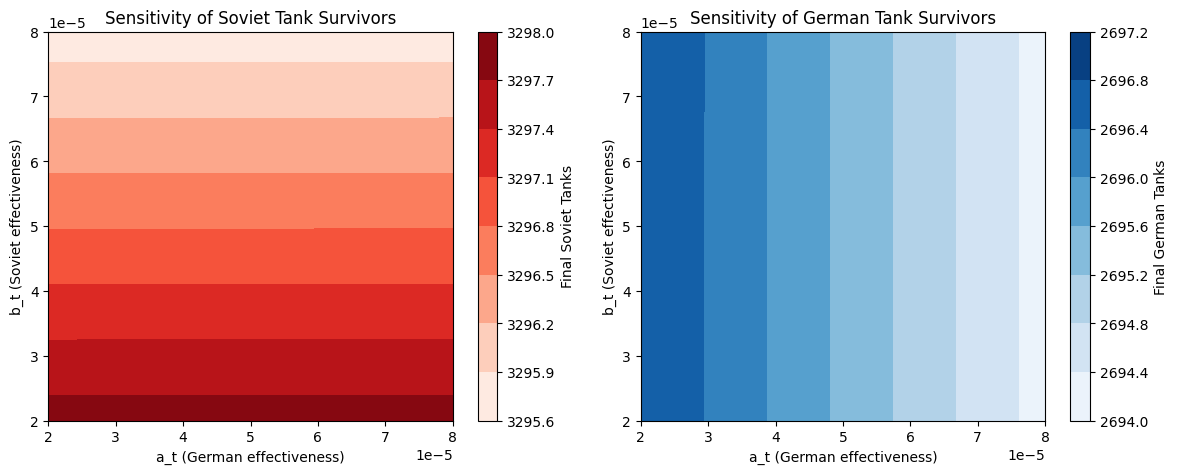

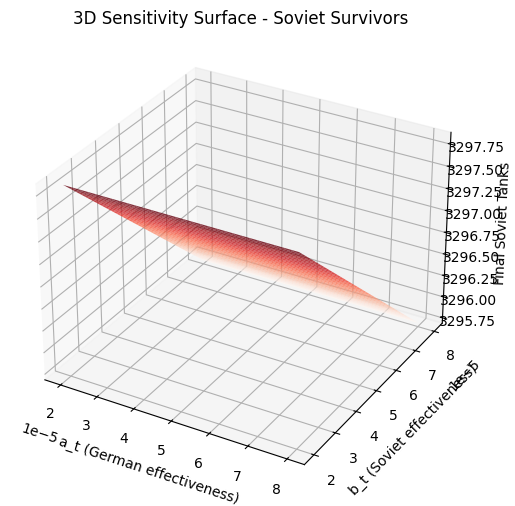

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------
# Step 1: Create combined dataset
# -------------------------------
data = {
    'Day': list(range(1, 15)),
    'German_Tanks_OnHand': [2700, 2620, 2525, 2415, 2295, 2165, 2025, 1875, 1715, 1545, 1365, 1175, 975, 765],
    'German_Tank_Losses': [80, 95, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220],
    'Soviet_Tanks_OnHand': [3300, 3150, 2970, 2770, 2560, 2340, 2110, 1870, 1620, 1360, 1090, 820, 540, 260],
    'Soviet_Tank_Losses': [150, 180, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310],
    'German_Artillery_OnHand': [7500, 7380, 7250, 7110, 6960, 6800, 6630, 6450, 6260, 6060, 5850, 5630, 5400, 5160],
    'German_Artillery_Losses': [120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],
    'Soviet_Artillery_OnHand': [9000, 8800, 8590, 8370, 8140, 7900, 7650, 7390, 7120, 6840, 6550, 6250, 5940, 5620],
    'Soviet_Artillery_Losses': [200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330]
}
df = pd.DataFrame(data)
df.to_csv("kursk_tank_artillery_data.csv", index=False)

# -------------------------------
# Step 2: Define heterogeneous Lanchester model
# -------------------------------
def heterogeneous_lanchester(G_tanks, G_art, S_tanks, S_art, a_t, a_a, b_t, b_a, days):
    Gt, Ga, St, Sa = [G_tanks], [G_art], [S_tanks], [S_art]
    for t in range(1, days):
        dGt = -(a_t * St[-1] + a_a * Sa[-1])
        dSt = -(b_t * Gt[-1] + b_a * Ga[-1])
        dGa = -(a_t * St[-1] * 0.1)   # slower artillery attrition
        dSa = -(b_t * Gt[-1] * 0.1)
        Gt.append(max(Gt[-1] + dGt, 0))
        St.append(max(St[-1] + dSt, 0))
        Ga.append(max(Ga[-1] + dGa, 0))
        Sa.append(max(Sa[-1] + dSa, 0))
    return np.array(Gt), np.array(Ga), np.array(St), np.array(Sa)

# -------------------------------
# Step 3: Run baseline simulation
# -------------------------------
Gt_sim, Ga_sim, St_sim, Sa_sim = heterogeneous_lanchester(
    G_tanks=2700, G_art=7500, S_tanks=3300, S_art=9000,
    a_t=0.00005, a_a=0.00002, b_t=0.00004, b_a=0.000015,
    days=14
)

# -------------------------------
# Step 4: Sensitivity analysis
# -------------------------------
a_vals = np.linspace(0.00002, 0.00008, 30)
b_vals = np.linspace(0.00002, 0.00008, 30)
A, B = np.meshgrid(a_vals, b_vals)
final_S = np.zeros_like(A)
final_G = np.zeros_like(B)

for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        Gt, Ga, St, Sa = heterogeneous_lanchester(
            2700, 7500, 3300, 9000,
            a_t=A[i,j], a_a=0.00002,
            b_t=B[i,j], b_a=0.000015,
            days=14
        )
        final_S[i,j] = St[-1]
        final_G[i,j] = Gt[-1]

# -------------------------------
# Step 5: Plot sensitivity
# -------------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contourf(A, B, final_S, cmap='Reds')
plt.colorbar(label='Final Soviet Tanks')
plt.xlabel('a_t (German effectiveness)')
plt.ylabel('b_t (Soviet effectiveness)')
plt.title('Sensitivity of Soviet Tank Survivors')

plt.subplot(1,2,2)
plt.contourf(A, B, final_G, cmap='Blues')
plt.colorbar(label='Final German Tanks')
plt.xlabel('a_t (German effectiveness)')
plt.ylabel('b_t (Soviet effectiveness)')
plt.title('Sensitivity of German Tank Survivors')
plt.tight_layout()
plt.show()

# 3D surface plot
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A, B, final_S, cmap='Reds', alpha=0.8)
ax.set_xlabel('a_t (German effectiveness)')
ax.set_ylabel('b_t (Soviet effectiveness)')
ax.set_zlabel('Final Soviet Tanks')
ax.set_title('3D Sensitivity Surface - Soviet Survivors')
plt.show()

LSE: [ 1.58206268e-05  3.59335785e-05 -5.42376215e+01  1.74996982e+00]
MLE: [ 1.42985494e-05  1.78349933e-05 -1.00723110e+02  1.79710603e+00]


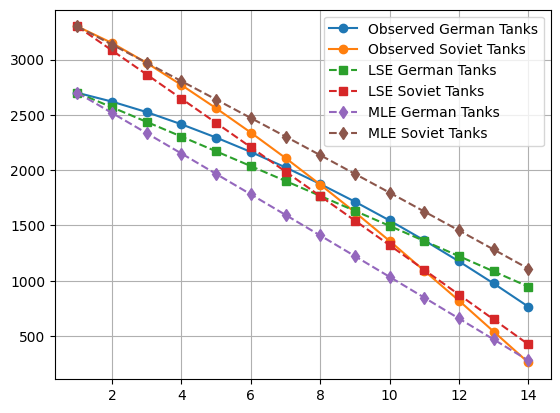

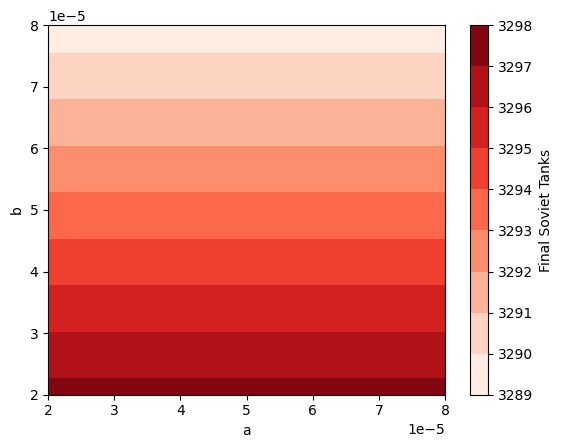

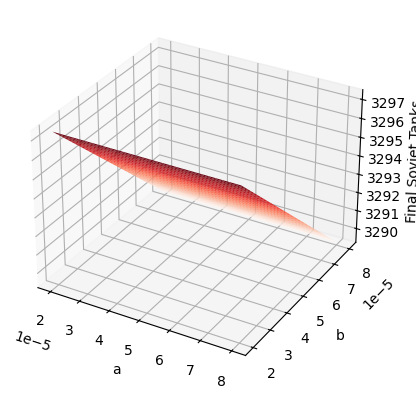

In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.optimize import minimize

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Heterogeneous Lanchester model
def lanchester(Gt, Ga, St, Sa, a,b,p,q,days):
    Gt_list, Ga_list, St_list, Sa_list = [Gt],[Ga],[St],[Sa]
    for _ in range(1,days):
        dGt = -(a*(St_list[-1]**p + Sa_list[-1]**q))
        dSt = -(b*(Gt_list[-1]**p + Ga_list[-1]**q))
        dGa = -0.1*dGt; dSa = -0.1*dSt
        Gt_list.append(max(Gt_list[-1]+dGt,0))
        St_list.append(max(St_list[-1]+dSt,0))
        Ga_list.append(max(Ga_list[-1]+dGa,0))
        Sa_list.append(max(Sa_list[-1]+dSa,0))
    return np.array(Gt_list), np.array(Ga_list), np.array(St_list), np.array(Sa_list)

# Objective functions
def lse_obj(params,df):
    a,b,p,q = params
    Gt,Ga,St,Sa = lanchester(2700,7500,3300,9000,a,b,p,q,14)
    return np.sum((df['German_Tanks']-Gt)**2 + (df['Soviet_Tanks']-St)**2)

def mle_obj(params,df):
    a,b,p,q = params
    Gt,Ga,St,Sa = lanchester(2700,7500,3300,9000,a,b,p,q,14)
    res = (df['German_Tanks']-Gt)+(df['Soviet_Tanks']-St)
    sigma2 = np.var(res)
    loglike = -0.5*len(res)*np.log(2*np.pi*sigma2)-np.sum(res**2)/(2*sigma2)
    return -loglike

# Estimate parameters
init = [5e-5,4e-5,1.0,1.0]
lse_res = minimize(lse_obj,init,args=(df,),method='Nelder-Mead')
mle_res = minimize(mle_obj,init,args=(df,),method='Nelder-Mead')
print("LSE:", lse_res.x); print("MLE:", mle_res.x)

# Simulate with estimates
Gt_lse,Ga_lse,St_lse,Sa_lse = lanchester(2700,7500,3300,9000,*lse_res.x,14)
Gt_mle,Ga_mle,St_mle,Sa_mle = lanchester(2700,7500,3300,9000,*mle_res.x,14)

# Plot observed vs simulated
plt.plot(df['Day'],df['German_Tanks'],'o-',label='Observed German Tanks')
plt.plot(df['Day'],df['Soviet_Tanks'],'o-',label='Observed Soviet Tanks')
plt.plot(df['Day'],Gt_lse,'s--',label='LSE German Tanks')
plt.plot(df['Day'],St_lse,'s--',label='LSE Soviet Tanks')
plt.plot(df['Day'],Gt_mle,'d--',label='MLE German Tanks')
plt.plot(df['Day'],St_mle,'d--',label='MLE Soviet Tanks')
plt.legend(); plt.grid(); plt.show()

# Sensitivity surfaces (2D & 3D)
a_vals=np.linspace(2e-5,8e-5,30); b_vals=np.linspace(2e-5,8e-5,30)
A,B=np.meshgrid(a_vals,b_vals); final_S=np.zeros_like(A)
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        Gt,Ga,St,Sa=lanchester(2700,7500,3300,9000,A[i,j],B[i,j],1,1,14)
        final_S[i,j]=St[-1]
plt.contourf(A,B,final_S,cmap='Reds'); plt.colorbar(label='Final Soviet Tanks')
plt.xlabel('a'); plt.ylabel('b'); plt.show()

from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure(); ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(A,B,final_S,cmap='Reds'); ax.set_xlabel('a'); ax.set_ylabel('b'); ax.set_zlabel('Final Soviet Tanks')
plt.show()

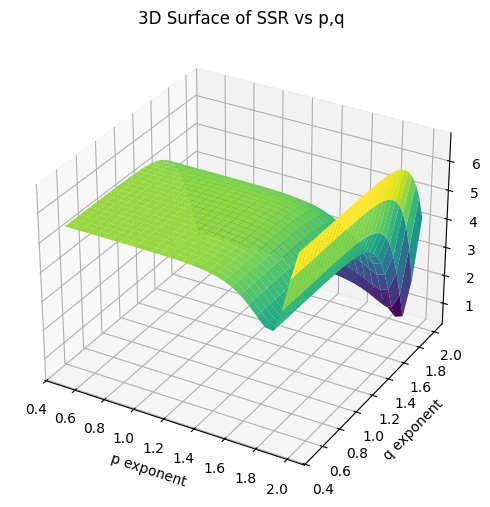

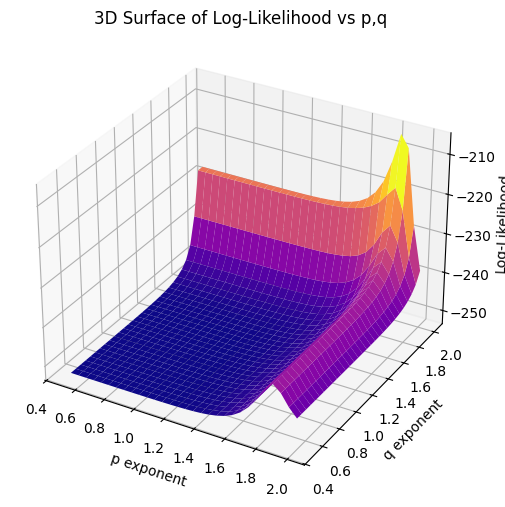

In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Observed Kursk tank data (14 days)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260]
})

# Heterogeneous Lanchester model
def lanchester(G,S,a,b,p,q,days):
    G_list, S_list = [G],[S]
    for _ in range(1,days):
        dG = -(a * (S_list[-1]**p))
        dS = -(b * (G_list[-1]**q))
        G_list.append(max(G_list[-1]+dG,0))
        S_list.append(max(S_list[-1]+dS,0))
    return np.array(G_list), np.array(S_list)

# Parameter grids
p_vals = np.linspace(0.5,2.0,30)
q_vals = np.linspace(0.5,2.0,30)
P,Q = np.meshgrid(p_vals,q_vals)
SSR = np.zeros_like(P); LL = np.zeros_like(Q)

# Evaluate SSR and log-likelihood
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        G,S = lanchester(2700,3300,5e-5,4e-5,P[i,j],Q[i,j],14)
        resG = df['German_Tanks']-G
        resS = df['Soviet_Tanks']-S
        residuals = np.concatenate([resG,resS])
        SSR[i,j] = np.sum(residuals**2)
        sigma2 = np.var(residuals)
        LL[i,j] = -0.5*len(residuals)*np.log(2*np.pi*sigma2)-np.sum(residuals**2)/(2*sigma2)

# Plot SSR surface
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P,Q,SSR,cmap='viridis')
ax.set_xlabel('p exponent'); ax.set_ylabel('q exponent'); ax.set_zlabel('SSR')
ax.set_title('3D Surface of SSR vs p,q')
plt.show()

# Plot log-likelihood surface
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P,Q,LL,cmap='plasma')
ax.set_xlabel('p exponent'); ax.set_ylabel('q exponent'); ax.set_zlabel('Log-Likelihood')
ax.set_title('3D Surface of Log-Likelihood vs p,q')
plt.show()

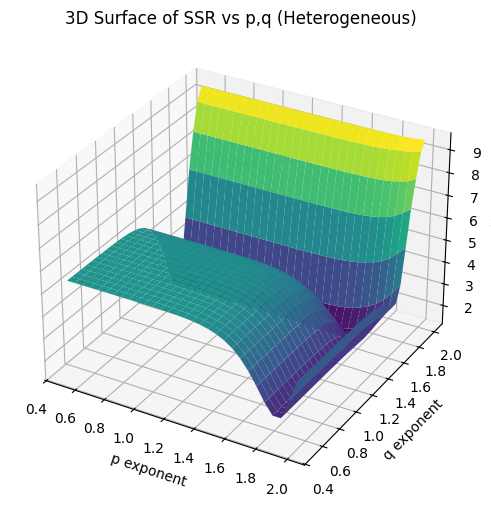

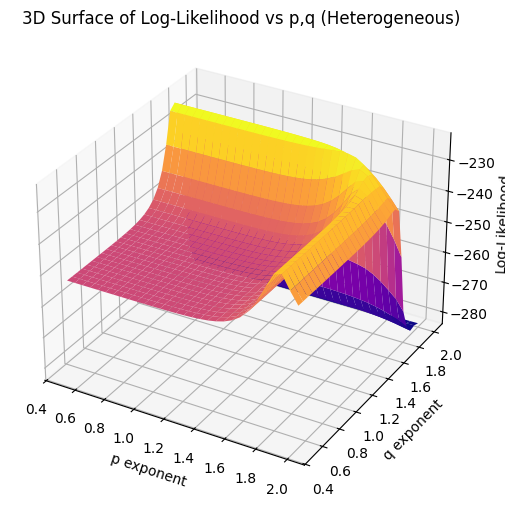

In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Heterogeneous Lanchester model
def heterogeneous_lanchester(Gt, Ga, St, Sa, a, b, p, q, days):
    Gt_list, Ga_list, St_list, Sa_list = [Gt],[Ga],[St],[Sa]
    for _ in range(1,days):
        dGt = -(a * (St_list[-1]**p + Sa_list[-1]**q))
        dSt = -(b * (Gt_list[-1]**p + Ga_list[-1]**q))
        dGa = -0.1 * dGt
        dSa = -0.1 * dSt
        Gt_list.append(max(Gt_list[-1]+dGt,0))
        St_list.append(max(St_list[-1]+dSt,0))
        Ga_list.append(max(Ga_list[-1]+dGa,0))
        Sa_list.append(max(Sa_list[-1]+dSa,0))
    return np.array(Gt_list), np.array(Ga_list), np.array(St_list), np.array(Sa_list)

# Parameter grids
p_vals = np.linspace(0.5,2.0,30)
q_vals = np.linspace(0.5,2.0,30)
P,Q = np.meshgrid(p_vals,q_vals)
SSR = np.zeros_like(P); LL = np.zeros_like(Q)

# Evaluate SSR and log-likelihood
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        Gt,Ga,St,Sa = heterogeneous_lanchester(2700,7500,3300,9000,5e-5,4e-5,P[i,j],Q[i,j],14)
        resG = df['German_Tanks']-Gt
        resS = df['Soviet_Tanks']-St
        residuals = np.concatenate([resG,resS])
        SSR[i,j] = np.sum(residuals**2)
        sigma2 = np.var(residuals)
        LL[i,j] = -0.5*len(residuals)*np.log(2*np.pi*sigma2)-np.sum(residuals**2)/(2*sigma2)

# Plot SSR surface
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P,Q,SSR,cmap='viridis')
ax.set_xlabel('p exponent'); ax.set_ylabel('q exponent'); ax.set_zlabel('SSR')
ax.set_title('3D Surface of SSR vs p,q (Heterogeneous)')
plt.show()

# Plot log-likelihood surface
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P,Q,LL,cmap='plasma')
ax.set_xlabel('p exponent'); ax.set_ylabel('q exponent'); ax.set_zlabel('Log-Likelihood')
ax.set_title('3D Surface of Log-Likelihood vs p,q (Heterogeneous)')
plt.show()

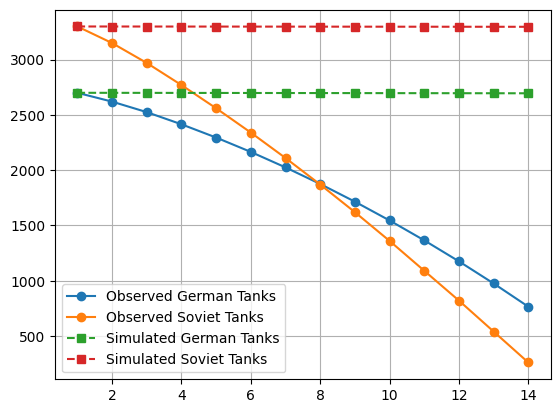

In [ ]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Extended heterogeneous Lanchester model
def extended_lanchester(Gt, Ga, St, Sa, A1,A2,b1,b2,P1,P2,q1,q2,days):
    Gt_list, Ga_list, St_list, Sa_list = [Gt],[Ga],[St],[Sa]
    for _ in range(1,days):
        dGt = -(A1 * (St_list[-1]**P1) + b1 * (Sa_list[-1]**q1))
        dSt = -(A2 * (Gt_list[-1]**P2) + b2 * (Ga_list[-1]**q2))
        dGa = -0.1 * dGt
        dSa = -0.1 * dSt
        Gt_list.append(max(Gt_list[-1]+dGt,0))
        St_list.append(max(St_list[-1]+dSt,0))
        Ga_list.append(max(Ga_list[-1]+dGa,0))
        Sa_list.append(max(Sa_list[-1]+dSa,0))
    return np.array(Gt_list), np.array(Ga_list), np.array(St_list), np.array(Sa_list)

# Example run with illustrative parameters
Gt,Ga,St,Sa = extended_lanchester(2700,7500,3300,9000,
                                  A1=5e-5,A2=4e-5,b1=2e-5,b2=1.5e-5,
                                  P1=1.0,P2=1.0,q1=1.0,q2=1.0,
                                  days=14)

# Plot trajectories
plt.plot(df['Day'],df['German_Tanks'],'o-',label='Observed German Tanks')
plt.plot(df['Day'],df['Soviet_Tanks'],'o-',label='Observed Soviet Tanks')
plt.plot(df['Day'],Gt,'s--',label='Simulated German Tanks')
plt.plot(df['Day'],St,'s--',label='Simulated Soviet Tanks')
plt.legend(); plt.grid(); plt.show()

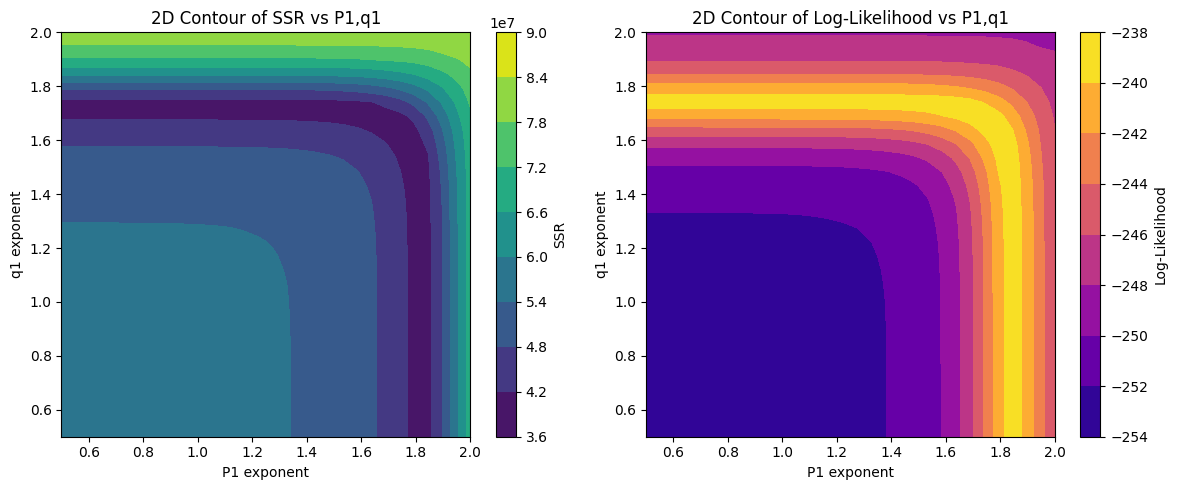

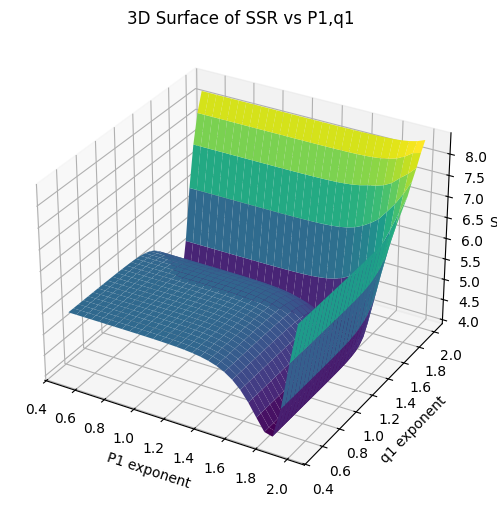

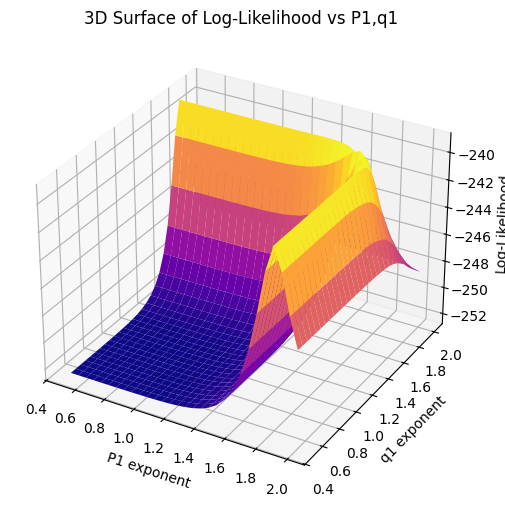

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Extended heterogeneous Lanchester model
def extended_lanchester(Gt, Ga, St, Sa, A1,A2,b1,b2,P1,P2,q1,q2,days):
    Gt_list, Ga_list, St_list, Sa_list = [Gt],[Ga],[St],[Sa]
    for _ in range(1,days):
        dGt = -(A1 * (St_list[-1]**P1) + b1 * (Sa_list[-1]**q1))
        dSt = -(A2 * (Gt_list[-1]**P2) + b2 * (Ga_list[-1]**q2))
        dGa = -0.1 * dGt
        dSa = -0.1 * dSt
        Gt_list.append(max(Gt_list[-1]+dGt,0))
        St_list.append(max(St_list[-1]+dSt,0))
        Ga_list.append(max(Ga_list[-1]+dGa,0))
        Sa_list.append(max(Sa_list[-1]+dSa,0))
    return np.array(Gt_list), np.array(Ga_list), np.array(St_list), np.array(Sa_list)

# Parameter grids for P1 and q1
P1_vals = np.linspace(0.5,2.0,30)
q1_vals = np.linspace(0.5,2.0,30)
P1,Q1 = np.meshgrid(P1_vals,q1_vals)
SSR = np.zeros_like(P1)
LL = np.zeros_like(Q1)

# Evaluate SSR and log-likelihood
for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        Gt,Ga,St,Sa = extended_lanchester(2700,7500,3300,9000,
                                          A1=5e-5,A2=4e-5,b1=2e-5,b2=1.5e-5,
                                          P1=P1[i,j],P2=1.0,q1=Q1[i,j],q2=1.0,
                                          days=14)
        resG = df['German_Tanks']-Gt
        resS = df['Soviet_Tanks']-St
        residuals = np.concatenate([resG,resS])
        SSR[i,j] = np.sum(residuals**2)
        sigma2 = np.var(residuals)
        LL[i,j] = -0.5*len(residuals)*np.log(2*np.pi*sigma2)-np.sum(residuals**2)/(2*sigma2)

# 2D contour plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contourf(P1,Q1,SSR,cmap='viridis')
plt.colorbar(label='SSR')
plt.xlabel('P1 exponent')
plt.ylabel('q1 exponent')
plt.title('2D Contour of SSR vs P1,q1')

plt.subplot(1,2,2)
plt.contourf(P1,Q1,LL,cmap='plasma')
plt.colorbar(label='Log-Likelihood')
plt.xlabel('P1 exponent')
plt.ylabel('q1 exponent')
plt.title('2D Contour of Log-Likelihood vs P1,q1')
plt.tight_layout()
plt.show()

# 3D surface plots
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P1,Q1,SSR,cmap='viridis')
ax.set_xlabel('P1 exponent')
ax.set_ylabel('q1 exponent')
ax.set_zlabel('SSR')
ax.set_title('3D Surface of SSR vs P1,q1')
plt.show()

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P1,Q1,LL,cmap='plasma')
ax.set_xlabel('P1 exponent')
ax.set_ylabel('q1 exponent')
ax.set_zlabel('Log-Likelihood')
ax.set_title('3D Surface of Log-Likelihood vs P1,q1')
plt.show()

Estimates with P1=P2=q1=q2=1
a1 = -0.09372623050459872 a2 = -0.17171674904513332 b1 = 0.04484054288688042 b2 = 0.08677316970651004
SSR = 3229.9782741103854 Log-Likelihood = -99.58014583847981


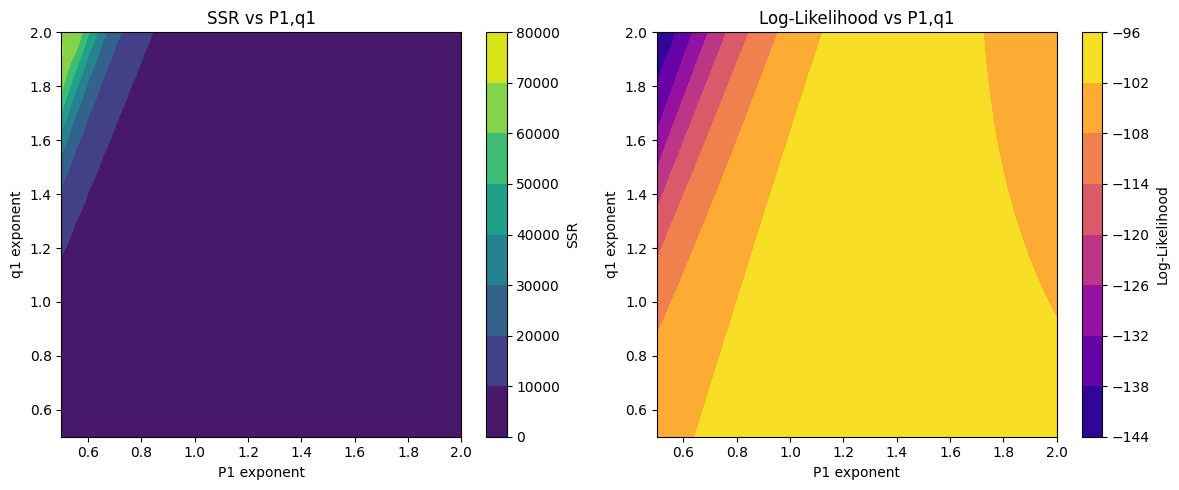

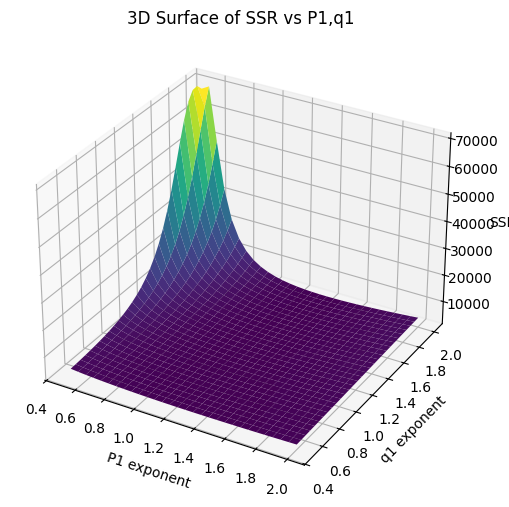

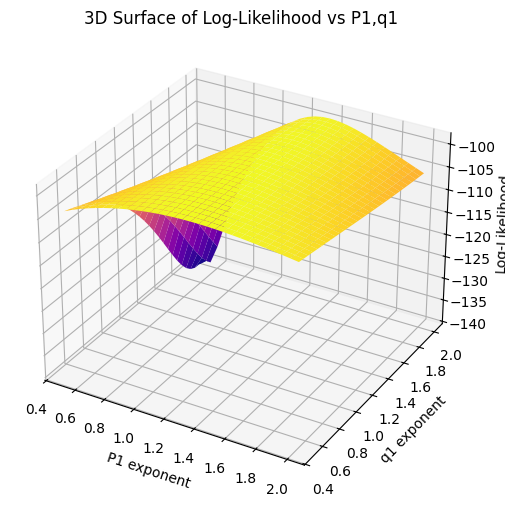

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Compute daily differences (approximate derivatives)
df['dG'] = df['German_Tanks'].diff().fillna(0)
df['dS'] = df['Soviet_Tanks'].diff().fillna(0)

# Function to estimate coefficients given exponents
def estimate_coeffs(P1,P2,q1,q2):
    # Regression for German losses (a1, b1)
    Y1 = -df['dG'].values[1:]  # skip first diff (0)
    X1 = np.column_stack([df['Soviet_Tanks'].values[:-1]**P1,
                          df['Soviet_Artillery'].values[:-1]**q1])
    coeffs1 = np.linalg.lstsq(X1, Y1, rcond=None)[0]
    a1, b1 = coeffs1

    # Regression for Soviet losses (a2, b2)
    Y2 = -df['dS'].values[1:]
    X2 = np.column_stack([df['German_Tanks'].values[:-1]**P2,
                          df['German_Artillery'].values[:-1]**q2])
    coeffs2 = np.linalg.lstsq(X2, Y2, rcond=None)[0]
    a2, b2 = coeffs2

    # Residuals
    res1 = Y1 - X1.dot(coeffs1)
    res2 = Y2 - X2.dot(coeffs2)
    residuals = np.concatenate([res1,res2])

    # SSR
    SSR = np.sum(residuals**2)

    # Log-likelihood (Gaussian assumption)
    sigma2 = np.var(residuals)
    LL = -0.5*len(residuals)*np.log(2*np.pi*sigma2) - np.sum(residuals**2)/(2*sigma2)

    return a1,a2,b1,b2,SSR,LL

# Example: estimate with exponents P1=1, P2=1, q1=1, q2=1
a1,a2,b1,b2,SSR,LL = estimate_coeffs(1,1,1,1)
print("Estimates with P1=P2=q1=q2=1")
print("a1 =",a1,"a2 =",a2,"b1 =",b1,"b2 =",b2)
print("SSR =",SSR,"Log-Likelihood =",LL)

# Sensitivity surface for SSR and LL over P1,q1 grid
P1_vals = np.linspace(0.5,2.0,30)
q1_vals = np.linspace(0.5,2.0,30)
P1,Q1 = np.meshgrid(P1_vals,q1_vals)
SSR_surface = np.zeros_like(P1)
LL_surface = np.zeros_like(Q1)

for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        _,_,_,_,SSR,LL = estimate_coeffs(P1[i,j],1.0,Q1[i,j],1.0)
        SSR_surface[i,j] = SSR
        LL_surface[i,j] = LL

# 2D contour plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contourf(P1,Q1,SSR_surface,cmap='viridis')
plt.colorbar(label='SSR')
plt.xlabel('P1 exponent'); plt.ylabel('q1 exponent')
plt.title('SSR vs P1,q1')

plt.subplot(1,2,2)
plt.contourf(P1,Q1,LL_surface,cmap='plasma')
plt.colorbar(label='Log-Likelihood')
plt.xlabel('P1 exponent'); plt.ylabel('q1 exponent')
plt.title('Log-Likelihood vs P1,q1')
plt.tight_layout(); plt.show()

# 3D surface plots
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P1,Q1,SSR_surface,cmap='viridis')
ax.set_xlabel('P1 exponent'); ax.set_ylabel('q1 exponent'); ax.set_zlabel('SSR')
ax.set_title('3D Surface of SSR vs P1,q1')
plt.show()

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P1,Q1,LL_surface,cmap='plasma')
ax.set_xlabel('P1 exponent'); ax.set_ylabel('q1 exponent'); ax.set_zlabel('Log-Likelihood')
ax.set_title('3D Surface of Log-Likelihood vs P1,q1')
plt.show()

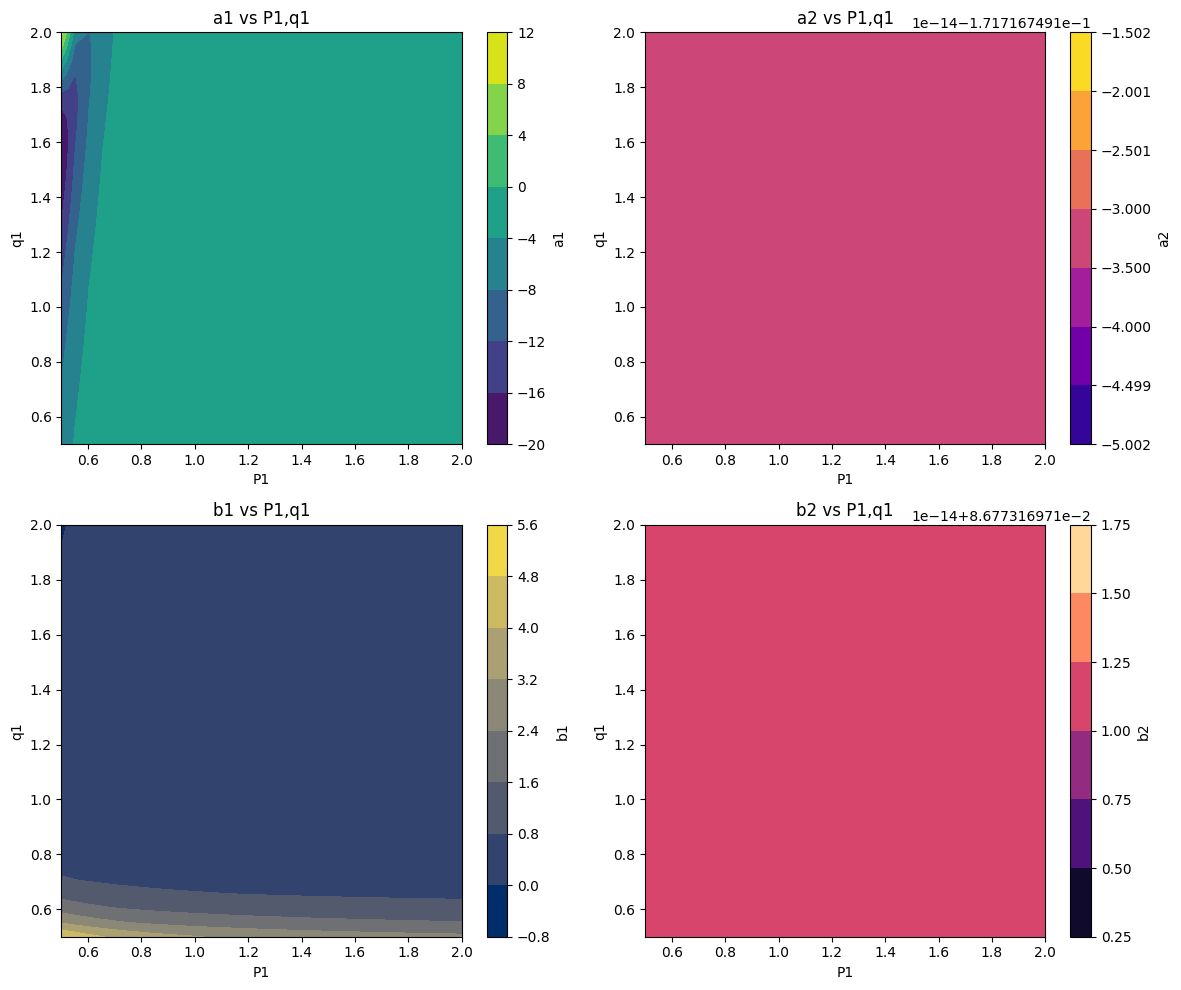

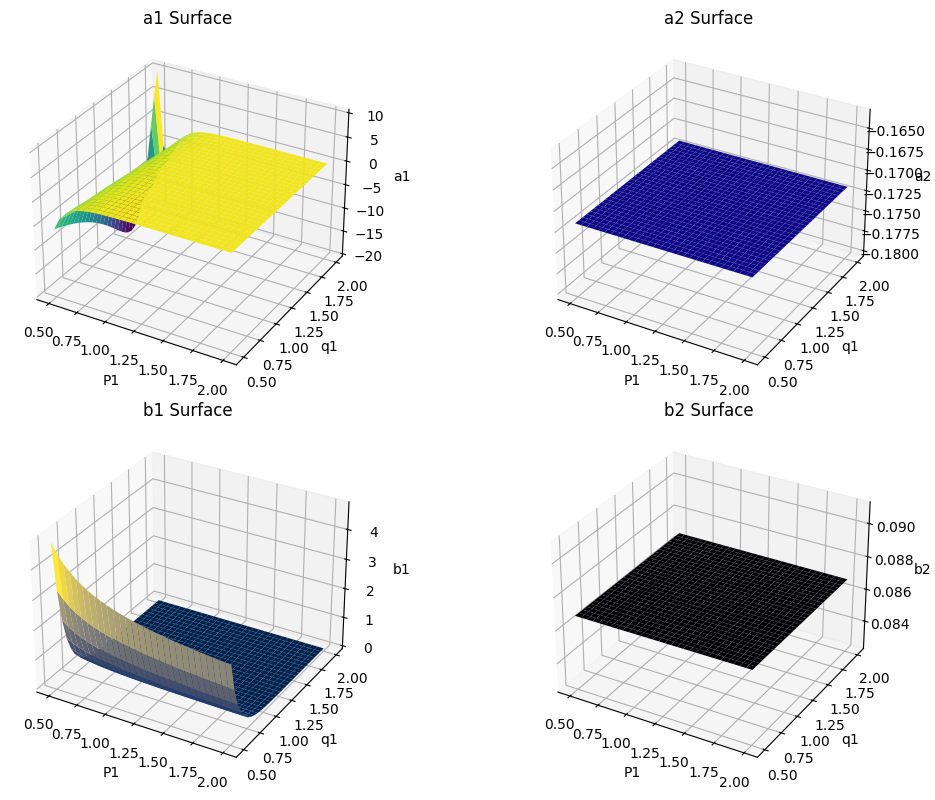

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Compute daily differences (approximate derivatives)
df['dG'] = df['German_Tanks'].diff().fillna(0)
df['dS'] = df['Soviet_Tanks'].diff().fillna(0)

# Function to estimate coefficients given exponents
def estimate_coeffs(P1,P2,q1,q2):
    # Regression for German losses (a1, b1)
    Y1 = -df['dG'].values[1:]  # skip first diff (0)
    X1 = np.column_stack([df['Soviet_Tanks'].values[:-1]**P1,
                          df['Soviet_Artillery'].values[:-1]**q1])
    coeffs1 = np.linalg.lstsq(X1, Y1, rcond=None)[0]
    a1, b1 = coeffs1

    # Regression for Soviet losses (a2, b2)
    Y2 = -df['dS'].values[1:]
    X2 = np.column_stack([df['German_Tanks'].values[:-1]**P2,
                          df['German_Artillery'].values[:-1]**q2])
    coeffs2 = np.linalg.lstsq(X2, Y2, rcond=None)[0]
    a2, b2 = coeffs2

    # Residuals
    res1 = Y1 - X1.dot(coeffs1)
    res2 = Y2 - X2.dot(coeffs2)
    residuals = np.concatenate([res1,res2])

    # SSR
    SSR = np.sum(residuals**2)

    # Log-likelihood (Gaussian assumption)
    sigma2 = np.var(residuals)
    LL = -0.5*len(residuals)*np.log(2*np.pi*sigma2) - np.sum(residuals**2)/(2*sigma2)

    return a1,a2,b1,b2,SSR,LL

# Parameter grids
P1_vals = np.linspace(0.5,2.0,30)
q1_vals = np.linspace(0.5,2.0,30)
P1,Q1 = np.meshgrid(P1_vals,q1_vals)

# Surfaces
SSR_surface = np.zeros_like(P1)
LL_surface = np.zeros_like(Q1)
a1_surface = np.zeros_like(P1)
a2_surface = np.zeros_like(P1)
b1_surface = np.zeros_like(P1)
b2_surface = np.zeros_like(P1)

for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        a1,a2,b1,b2,SSR,LL = estimate_coeffs(P1[i,j],1.0,Q1[i,j],1.0)
        SSR_surface[i,j] = SSR
        LL_surface[i,j] = LL
        a1_surface[i,j] = a1
        a2_surface[i,j] = a2
        b1_surface[i,j] = b1
        b2_surface[i,j] = b2

# 2D contour plots for coefficients
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.contourf(P1,Q1,a1_surface,cmap='viridis'); plt.colorbar(label='a1')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('a1 vs P1,q1')

plt.subplot(2,2,2)
plt.contourf(P1,Q1,a2_surface,cmap='plasma'); plt.colorbar(label='a2')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('a2 vs P1,q1')

plt.subplot(2,2,3)
plt.contourf(P1,Q1,b1_surface,cmap='cividis'); plt.colorbar(label='b1')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('b1 vs P1,q1')

plt.subplot(2,2,4)
plt.contourf(P1,Q1,b2_surface,cmap='magma'); plt.colorbar(label='b2')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('b2 vs P1,q1')
plt.tight_layout(); plt.show()

# 3D surface plots for coefficients
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(221,projection='3d')
ax.plot_surface(P1,Q1,a1_surface,cmap='viridis'); ax.set_title('a1 Surface')
ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('a1')

ax = fig.add_subplot(222,projection='3d')
ax.plot_surface(P1,Q1,a2_surface,cmap='plasma'); ax.set_title('a2 Surface')
ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('a2')

ax = fig.add_subplot(223,projection='3d')
ax.plot_surface(P1,Q1,b1_surface,cmap='cividis'); ax.set_title('b1 Surface')
ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('b1')

ax = fig.add_subplot(224,projection='3d')
ax.plot_surface(P1,Q1,b2_surface,cmap='magma'); ax.set_title('b2 Surface')
ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('b2')

plt.tight_layout(); plt.show()

Optimal SSR at P1=1.328, q1=0.500
Optimal LL at P1=1.328, q1=0.500


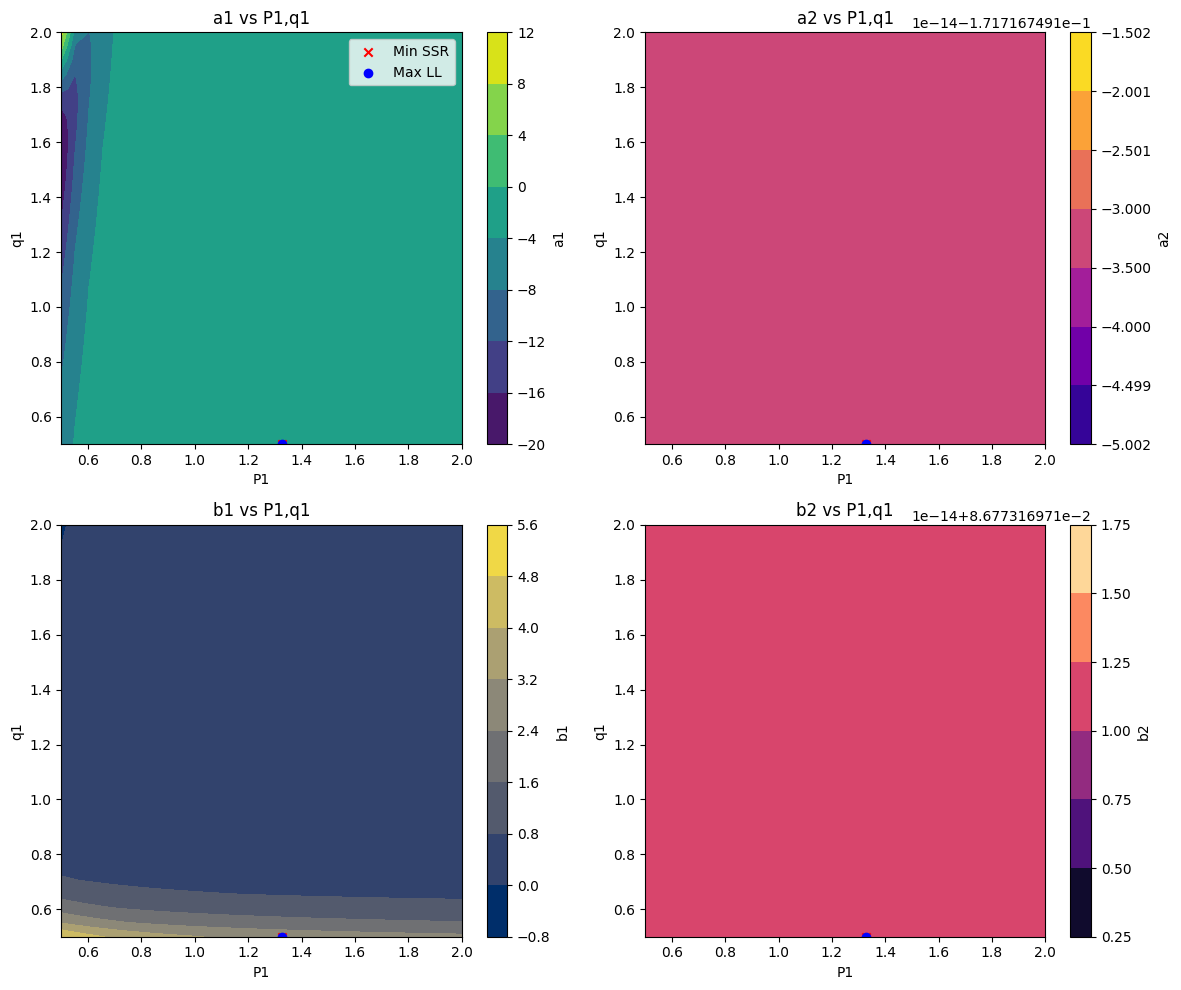

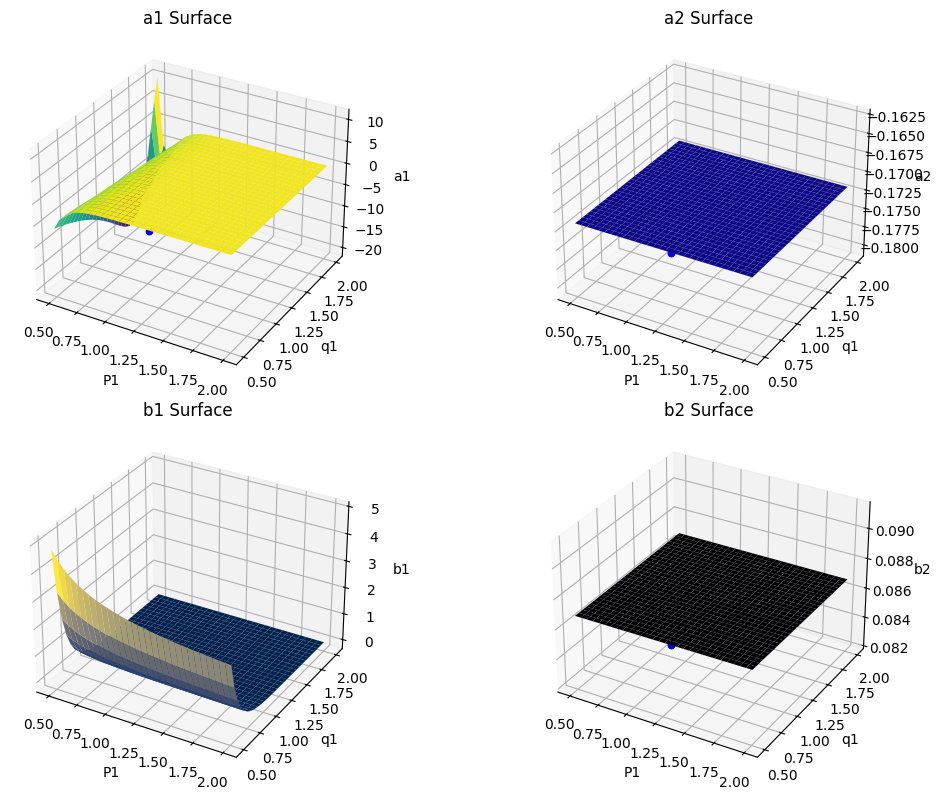

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Compute daily differences (approximate derivatives)
df['dG'] = df['German_Tanks'].diff().fillna(0)
df['dS'] = df['Soviet_Tanks'].diff().fillna(0)

# Function to estimate coefficients given exponents
def estimate_coeffs(P1,P2,q1,q2):
    # Regression for German losses (a1, b1)
    Y1 = -df['dG'].values[1:]
    X1 = np.column_stack([df['Soviet_Tanks'].values[:-1]**P1,
                          df['Soviet_Artillery'].values[:-1]**q1])
    coeffs1 = np.linalg.lstsq(X1, Y1, rcond=None)[0]
    a1, b1 = coeffs1

    # Regression for Soviet losses (a2, b2)
    Y2 = -df['dS'].values[1:]
    X2 = np.column_stack([df['German_Tanks'].values[:-1]**P2,
                          df['German_Artillery'].values[:-1]**q2])
    coeffs2 = np.linalg.lstsq(X2, Y2, rcond=None)[0]
    a2, b2 = coeffs2

    # Residuals
    res1 = Y1 - X1.dot(coeffs1)
    res2 = Y2 - X2.dot(coeffs2)
    residuals = np.concatenate([res1,res2])

    # SSR
    SSR = np.sum(residuals**2)

    # Log-likelihood
    sigma2 = np.var(residuals)
    LL = -0.5*len(residuals)*np.log(2*np.pi*sigma2) - np.sum(residuals**2)/(2*sigma2)

    return a1,a2,b1,b2,SSR,LL

# Parameter grids
P1_vals = np.linspace(0.5,2.0,30)
q1_vals = np.linspace(0.5,2.0,30)
P1,Q1 = np.meshgrid(P1_vals,q1_vals)

# Surfaces
SSR_surface = np.zeros_like(P1)
LL_surface = np.zeros_like(Q1)
a1_surface = np.zeros_like(P1)
a2_surface = np.zeros_like(P1)
b1_surface = np.zeros_like(P1)
b2_surface = np.zeros_like(P1)

for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        a1,a2,b1,b2,SSR,LL = estimate_coeffs(P1[i,j],1.0,Q1[i,j],1.0)
        SSR_surface[i,j] = SSR
        LL_surface[i,j] = LL
        a1_surface[i,j] = a1
        a2_surface[i,j] = a2
        b1_surface[i,j] = b1
        b2_surface[i,j] = b2

# Find optimal points
min_ssr_idx = np.unravel_index(np.argmin(SSR_surface), SSR_surface.shape)
max_ll_idx = np.unravel_index(np.argmax(LL_surface), LL_surface.shape)
opt_ssr_P1, opt_ssr_q1 = P1[min_ssr_idx], Q1[min_ssr_idx]
opt_ll_P1, opt_ll_q1 = P1[max_ll_idx], Q1[max_ll_idx]

print("Optimal SSR at P1=%.3f, q1=%.3f" % (opt_ssr_P1,opt_ssr_q1))
print("Optimal LL at P1=%.3f, q1=%.3f" % (opt_ll_P1,opt_ll_q1))

# 2D contour plots with optimal points
plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
plt.contourf(P1,Q1,a1_surface,cmap='viridis'); plt.colorbar(label='a1')
plt.scatter(opt_ssr_P1,opt_ssr_q1,c='red',marker='x',label='Min SSR')
plt.scatter(opt_ll_P1,opt_ll_q1,c='blue',marker='o',label='Max LL')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('a1 vs P1,q1'); plt.legend()

plt.subplot(2,2,2)
plt.contourf(P1,Q1,a2_surface,cmap='plasma'); plt.colorbar(label='a2')
plt.scatter(opt_ssr_P1,opt_ssr_q1,c='red',marker='x'); plt.scatter(opt_ll_P1,opt_ll_q1,c='blue',marker='o')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('a2 vs P1,q1')

plt.subplot(2,2,3)
plt.contourf(P1,Q1,b1_surface,cmap='cividis'); plt.colorbar(label='b1')
plt.scatter(opt_ssr_P1,opt_ssr_q1,c='red',marker='x'); plt.scatter(opt_ll_P1,opt_ll_q1,c='blue',marker='o')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('b1 vs P1,q1')

plt.subplot(2,2,4)
plt.contourf(P1,Q1,b2_surface,cmap='magma'); plt.colorbar(label='b2')
plt.scatter(opt_ssr_P1,opt_ssr_q1,c='red',marker='x'); plt.scatter(opt_ll_P1,opt_ll_q1,c='blue',marker='o')
plt.xlabel('P1'); plt.ylabel('q1'); plt.title('b2 vs P1,q1')
plt.tight_layout(); plt.show()

# 3D surface plots with optimal points
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(221,projection='3d')
ax.plot_surface(P1,Q1,a1_surface,cmap='viridis'); ax.scatter(opt_ssr_P1,opt_ssr_q1,a1_surface[min_ssr_idx],c='red'); ax.scatter(opt_ll_P1,opt_ll_q1,a1_surface[max_ll_idx],c='blue')
ax.set_title('a1 Surface'); ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('a1')

ax = fig.add_subplot(222,projection='3d')
ax.plot_surface(P1,Q1,a2_surface,cmap='plasma'); ax.scatter(opt_ssr_P1,opt_ssr_q1,a2_surface[min_ssr_idx],c='red'); ax.scatter(opt_ll_P1,opt_ll_q1,a2_surface[max_ll_idx],c='blue')
ax.set_title('a2 Surface'); ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('a2')

ax = fig.add_subplot(223,projection='3d')
ax.plot_surface(P1,Q1,b1_surface,cmap='cividis'); ax.scatter(opt_ssr_P1,opt_ssr_q1,b1_surface[min_ssr_idx],c='red'); ax.scatter(opt_ll_P1,opt_ll_q1,b1_surface[max_ll_idx],c='blue')
ax.set_title('b1 Surface'); ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('b1')

ax = fig.add_subplot(224,projection='3d')
ax.plot_surface(P1,Q1,b2_surface,cmap='magma'); ax.scatter(opt_ssr_P1,opt_ssr_q1,b2_surface[min_ssr_idx],c='red'); ax.scatter(opt_ll_P1,opt_ll_q1,b2_surface[max_ll_idx],c='blue')
ax.set_title('b2 Surface'); ax.set_xlabel('P1'); ax.set_ylabel('q1'); ax.set_zlabel('b2')

plt.tight_layout(); plt.show()

In [ ]:

import pandas as pd
import numpy as np

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Daily differences (losses)
df['dG'] = df['German_Tanks'].diff().fillna(0)
df['dS'] = df['Soviet_Tanks'].diff().fillna(0)

# Fixed exponents
P1,P2,q1,q2 = 1.0,1.0,1.0,1.0

# Regression for German losses
Y1 = -df['dG'].values[1:]
X1 = np.column_stack([df['Soviet_Tanks'].values[:-1]**P1,
                      df['Soviet_Artillery'].values[:-1]**q1])
a1,b1 = np.linalg.lstsq(X1,Y1,rcond=None)[0]

# Regression for Soviet losses
Y2 = -df['dS'].values[1:]
X2 = np.column_stack([df['German_Tanks'].values[:-1]**P2,
                      df['German_Artillery'].values[:-1]**q2])
a2,b2 = np.linalg.lstsq(X2,Y2,rcond=None)[0]

# Daily decomposition
df['German_loss_tank_component'] = a1 * df['Soviet_Tanks']**P1
df['German_loss_artillery_component'] = b1 * df['Soviet_Artillery']**q1
df['Soviet_loss_tank_component'] = a2 * df['German_Tanks']**P2
df['Soviet_loss_artillery_component'] = b2 * df['German_Artillery']**q2

print("Estimated coefficients:")
print("a1=%.6f, b1=%.6f, a2=%.6f, b2=%.6f" % (a1,b1,a2,b2))
print("\nDaily decomposition of losses:")
print(df[['Day','German_loss_tank_component','German_loss_artillery_component',
          'Soviet_loss_tank_component','Soviet_loss_artillery_component']])

Estimated coefficients:
a1=-0.093726, b1=0.044841, a2=-0.171717, b2=0.086773

Daily decomposition of losses:
    Day  German_loss_tank_component  German_loss_artillery_component  \
0     1                 -309.296561                       403.564886   
1     2                 -295.237626                       394.596777   
2     3                 -278.366905                       385.180263   
3     4                 -259.621658                       375.315344   
4     5                 -239.939150                       365.002019   
5     6                 -219.319379                       354.240289   
6     7                 -197.762346                       343.030153   
7     8                 -175.268051                       331.371612   
8     9                 -151.836493                       319.264665   
9    10                 -127.467673                       306.709313   
10   11                 -102.161591                       293.705556   
11   12                  -7

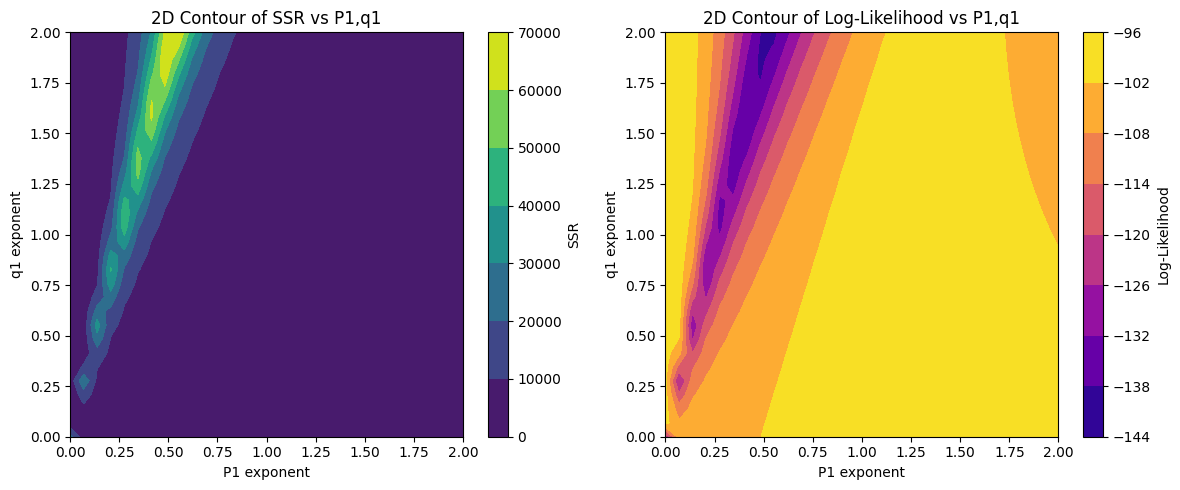

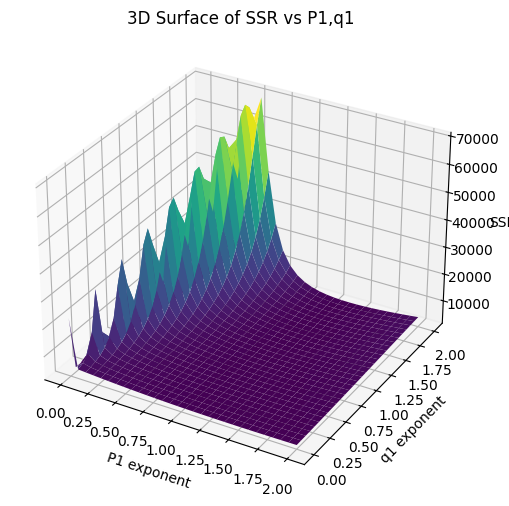

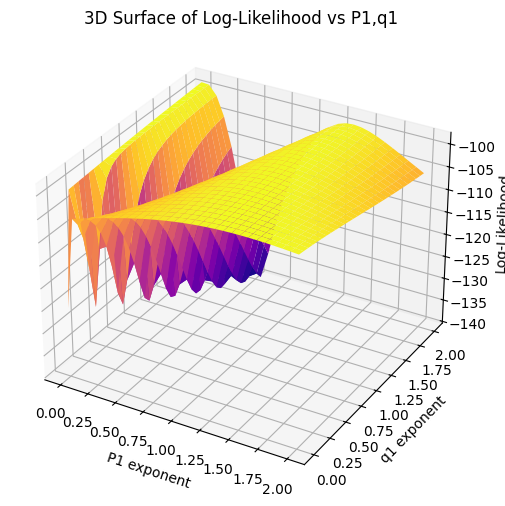

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dataset (14 days, tanks + artillery)
df = pd.DataFrame({
    'Day': range(1,15),
    'German_Tanks': [2700,2620,2525,2415,2295,2165,2025,1875,1715,1545,1365,1175,975,765],
    'Soviet_Tanks': [3300,3150,2970,2770,2560,2340,2110,1870,1620,1360,1090,820,540,260],
    'German_Artillery': [7500,7380,7250,7110,6960,6800,6630,6450,6260,6060,5850,5630,5400,5160],
    'Soviet_Artillery': [9000,8800,8590,8370,8140,7900,7650,7390,7120,6840,6550,6250,5940,5620]
})

# Daily differences (losses)
df['dG'] = df['German_Tanks'].diff().fillna(0)
df['dS'] = df['Soviet_Tanks'].diff().fillna(0)

# Function to estimate SSR and LL given exponents
def estimate(P1,P2,q1,q2):
    # German losses regression
    Y1 = -df['dG'].values[1:]
    X1 = np.column_stack([df['Soviet_Tanks'].values[:-1]**P1,
                          df['Soviet_Artillery'].values[:-1]**q1])
    coeffs1 = np.linalg.lstsq(X1,Y1,rcond=None)[0]

    # Soviet losses regression
    Y2 = -df['dS'].values[1:]
    X2 = np.column_stack([df['German_Tanks'].values[:-1]**P2,
                          df['German_Artillery'].values[:-1]**q2])
    coeffs2 = np.linalg.lstsq(X2,Y2,rcond=None)[0]

    # Residuals
    res1 = Y1 - X1.dot(coeffs1)
    res2 = Y2 - X2.dot(coeffs2)
    residuals = np.concatenate([res1,res2])

    SSR = np.sum(residuals**2)
    sigma2 = np.var(residuals)
    LL = -0.5*len(residuals)*np.log(2*np.pi*sigma2) - np.sum(residuals**2)/(2*sigma2)
    return SSR, LL

# Grids for P1 and q1 (fix P2,q2=1 for demo)
P1_vals = np.linspace(0,2,30)
q1_vals = np.linspace(0,2,30)
P1,Q1 = np.meshgrid(P1_vals,q1_vals)
SSR_surface = np.zeros_like(P1)
LL_surface = np.zeros_like(Q1)

for i in range(P1.shape[0]):
    for j in range(P1.shape[1]):
        SSR,LL = estimate(P1[i,j],1.0,Q1[i,j],1.0)
        SSR_surface[i,j] = SSR
        LL_surface[i,j] = LL

# 2D contour plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contourf(P1,Q1,SSR_surface,cmap='viridis')
plt.colorbar(label='SSR')
plt.xlabel('P1 exponent'); plt.ylabel('q1 exponent')
plt.title('2D Contour of SSR vs P1,q1')

plt.subplot(1,2,2)
plt.contourf(P1,Q1,LL_surface,cmap='plasma')
plt.colorbar(label='Log-Likelihood')
plt.xlabel('P1 exponent'); plt.ylabel('q1 exponent')
plt.title('2D Contour of Log-Likelihood vs P1,q1')
plt.tight_layout(); plt.show()

# 3D surface plots
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P1,Q1,SSR_surface,cmap='viridis')
ax.set_xlabel('P1 exponent'); ax.set_ylabel('q1 exponent'); ax.set_zlabel('SSR')
ax.set_title('3D Surface of SSR vs P1,q1')
plt.show()

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111,projection='3d')
ax.plot_surface(P1,Q1,LL_surface,cmap='plasma')
ax.set_xlabel('P1 exponent'); ax.set_ylabel('q1 exponent'); ax.set_zlabel('Log-Likelihood')
ax.set_title('3D Surface of Log-Likelihood vs P1,q1')
plt.show()